In [42]:
import pandas as pd 
import matplotlib.pyplot as plt


In [43]:
data=pd.read_csv("../data/clean/cleandata.csv",index_col="time", parse_dates=True)


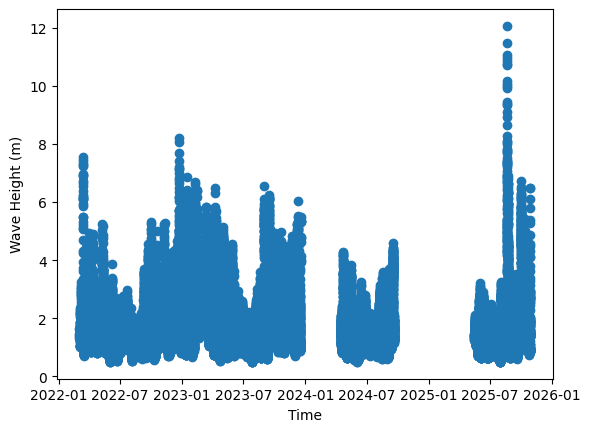

In [44]:
plt.scatter(data.index, data['Significant wave height'])
plt.xlabel("Time")
plt.ylabel("Wave Height (m)")
plt.show()

# Decomposition

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

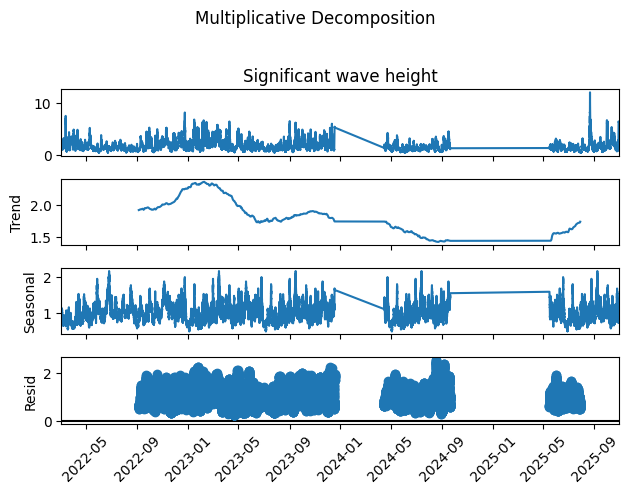

In [46]:
decomposition_multi = seasonal_decompose(data['Significant wave height'],
     model='multiplicative', period=24*365)
fig = decomposition_multi.plot()
fig.suptitle("Multiplicative Decomposition", y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

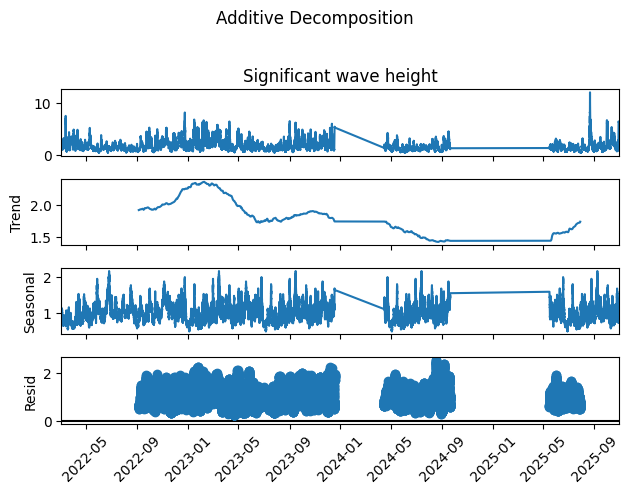

In [47]:
decomposition_add = seasonal_decompose(data['Significant wave height'],
     model='additive',period=24*365)
fig = decomposition_multi.plot()
fig.suptitle("Additive Decomposition", y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Note on the 2024–2025 gap: the buoy has no recorded data from ~Sept 2024–mid 2025 (raw files stop early). Decomposition results for 2022–2024 (dense real data) are considered reliable; anything spanning or immediately adjacent to the gap should be read with that caveat.

# Autocorrelation

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


(0.0, 1.0)

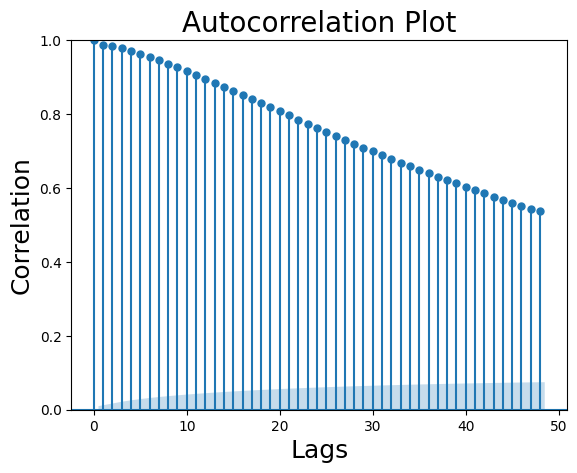

In [49]:
plot_acf(data['Significant wave height'].dropna(), lags=48)
plt.title('Autocorrelation Plot', fontsize=20)
plt.xlabel('Lags', fontsize=18)
plt.ylabel('Correlation', fontsize=18)
plt.ylim(0,1)

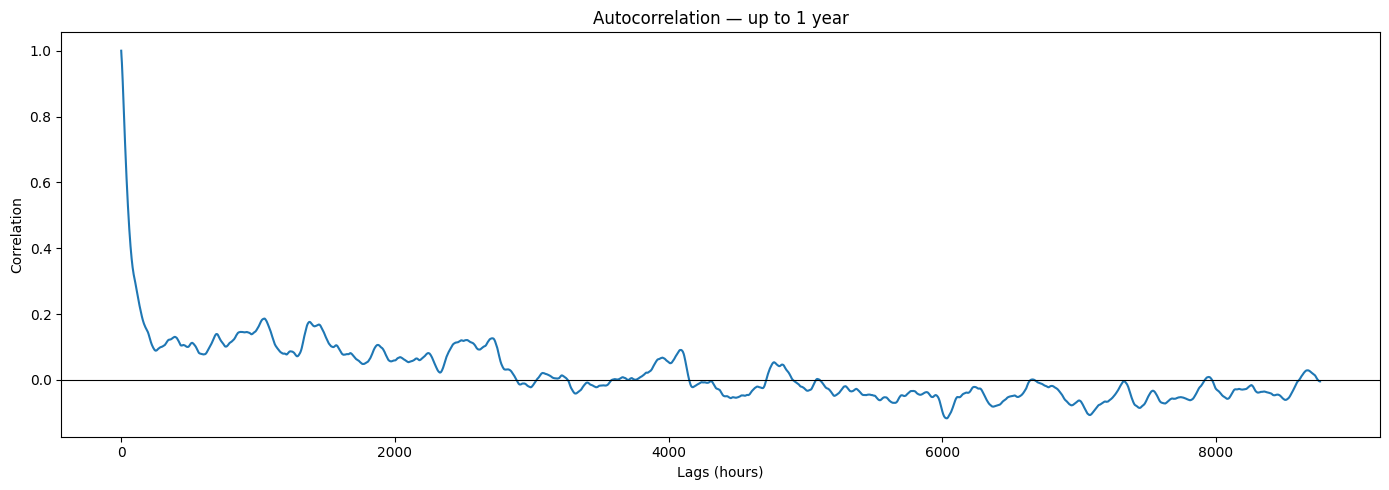

In [50]:

acf_vals = acf(data['Significant wave height'].dropna(), nlags=24*365, fft=True)

plt.figure(figsize=(14,5))
plt.plot(acf_vals)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Lags (hours)')
plt.ylabel('Correlation')
plt.title('Autocorrelation — up to 1 year')
plt.tight_layout()
plt.show()